In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy as np
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)



c:\Users\Samuel\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# 1. Definir las rutas de los archivos CSV preprocesados
path_train = "../../Data/Procesado/dfFinalMA_Train/MA_Train.csv"
path_test  = "../../Data/Procesado/dfFinalMA_Test/MA_Test.csv"

# 2. Cargar los datasets
df_train = pd.read_csv(path_train)
df_test  = pd.read_csv(path_test)

# 3. Verificación de carga
print("==============================================")
print("        DATASETS CARGADOS CON ÉXITO           ")
print("==============================================")
print(f"Dimensiones de Train: {df_train.shape[0]} filas, {df_train.shape[1]} columnas")
print(f"Dimensiones de Test:  {df_test.shape[0]} filas, {df_test.shape[1]} columnas")

print("\n--- Tipos de datos en Train ---")
print(df_train.dtypes)

print("\n--- Primeras 5 filas de Train ---")
display(df_train.head())

        DATASETS CARGADOS CON ÉXITO           
Dimensiones de Train: 6375 filas, 15 columnas
Dimensiones de Test:  1608 filas, 15 columnas

--- Tipos de datos en Train ---
User_ID                       object
Age                            int64
Gender                        object
User_Archetype                object
Primary_Platform              object
Daily_Screen_Time_Hours      float64
Dominant_Content_Type         object
Activity_Type                 object
Late_Night_Usage                bool
Social_Comparison_Trigger       bool
Sleep_Duration_Hours         float64
GAD_7_Score                    int64
GAD_7_Severity                object
PHQ_9_Score                    int64
PHQ_9_Severity                object
dtype: object

--- Primeras 5 filas de Train ---


,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-00061085,19,MALE,PASSIVE SCROLLER,FACEBOOK,4.0,NEWS/POLITICS,PASSIVE,True,False,5.8,8,MILD,8,MILD
1,U-00088ACC,20,MALE,PASSIVE SCROLLER,TIKTOK,4.0,NEWS/POLITICS,PASSIVE,True,False,4.2,10,MODERATE,7,MILD
2,U-000A7FEC,20,MALE,AVERAGE USER,INSTAGRAM,3.6,LIFESTYLE/FASHION,ACTIVE,False,True,6.9,10,MODERATE,0,NONE-MINIMAL
3,U-00228E6E,19,MALE,PASSIVE SCROLLER,YOUTUBE,3.1,LIFESTYLE/FASHION,PASSIVE,False,False,6.2,7,MILD,9,MILD
4,U-00262C0F,18,FEMALE,AVERAGE USER,LINKEDIN,2.4,EDUCATIONAL/TECH,ACTIVE,False,False,6.4,9,MILD,1,NONE-MINIMAL


In [4]:
# 1. Definir la variable objetivo
le = LabelEncoder()
df_train['GAD_7_Severity'] = le.fit_transform(df_train['GAD_7_Severity'])
df_test['GAD_7_Severity'] = le.transform(df_test['GAD_7_Severity'])
target_col = "GAD_7_Severity"

columnas_a_dropear = [
    "User_ID",                 
    "GAD_7_Score",
    "PHQ_9_Score",
    "PHQ_9_Severity"
]

# 3. Separar X (Características) e y (Variable Objetivo) para TRAIN
X_train = df_train.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_train = df_train[target_col]

# 4. Separar X e y para TEST
X_test = df_test.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_test = df_test[target_col]

# 5. Comprobación
print("==============================================")
print("        SEPARACIÓN Y LIMPIEZA COMPLETADA      ")
print("==============================================")
print(f"Dimensiones de X_train (Predictoras): {X_train.shape}")
print(f"Dimensiones de y_train (Objetivo):    {y_train.shape}")
print(f"Dimensiones de X_test (Predictoras):  {X_test.shape}")
print(f"Dimensiones de y_test (Objetivo):     {y_test.shape}")

print("\nColumnas que usará el modelo para aprender:")
print(list(X_train.columns))

        SEPARACIÓN Y LIMPIEZA COMPLETADA      
Dimensiones de X_train (Predictoras): (6375, 10)
Dimensiones de y_train (Objetivo):    (6375,)
Dimensiones de X_test (Predictoras):  (1608, 10)
Dimensiones de y_test (Objetivo):     (1608,)

Columnas que usará el modelo para aprender:
['Age', 'Gender', 'User_Archetype', 'Primary_Platform', 'Daily_Screen_Time_Hours', 'Dominant_Content_Type', 'Activity_Type', 'Late_Night_Usage', 'Social_Comparison_Trigger', 'Sleep_Duration_Hours']


In [5]:
# 1. Identificar cuáles son las columnas numéricas
# Seleccionamos solo las columnas de tipo entero y decimal
columnas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns

print(f"Se van a escalar las siguientes columnas numéricas:\n{list(columnas_numericas)}\n")

# 2. Inicializar el StandardScaler
scaler = StandardScaler()

# 3. AjustaR  y transformar 
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

# ==========================================
# 5. Comprobación de que se hizo correctamente
# ==========================================
print("--- Comprobación en TRAIN ---")
print("La media de Train debería ser muy cercana a 0:")
print(X_train[columnas_numericas].mean().round(2))
print("\nLa desviación estándar de Train debería ser 1:")
print(X_train[columnas_numericas].std().round(2))

print("\n--- Primeras filas de X_train escalado ---")
display(X_train.head()) 

Se van a escalar las siguientes columnas numéricas:
['Age', 'Daily_Screen_Time_Hours', 'Sleep_Duration_Hours']

--- Comprobación en TRAIN ---
La media de Train debería ser muy cercana a 0:
Age                       -0.0
Daily_Screen_Time_Hours    0.0
Sleep_Duration_Hours       0.0
dtype: float64

La desviación estándar de Train debería ser 1:
Age                        1.0
Daily_Screen_Time_Hours    1.0
Sleep_Duration_Hours       1.0
dtype: float64

--- Primeras filas de X_train escalado ---


,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours
0,-0.050239,MALE,PASSIVE SCROLLER,FACEBOOK,-0.107376,NEWS/POLITICS,PASSIVE,True,False,-0.015770
1,0.846880,MALE,PASSIVE SCROLLER,TIKTOK,-0.107376,NEWS/POLITICS,PASSIVE,True,False,-1.215309
2,0.846880,MALE,AVERAGE USER,INSTAGRAM,-0.281100,LIFESTYLE/FASHION,ACTIVE,False,True,0.808913
3,-0.050239,MALE,PASSIVE SCROLLER,YOUTUBE,-0.498256,LIFESTYLE/FASHION,PASSIVE,False,False,0.284114
4,-0.947357,FEMALE,AVERAGE USER,LINKEDIN,-0.802275,EDUCATIONAL/TECH,ACTIVE,False,False,0.434057


In [6]:
# 1. Definir qué columnas son categóricas
columnas_categoricas = ['Gender', 'User_Archetype', 'Primary_Platform', 'Dominant_Content_Type','Activity_Type']

# 2. Aplicar One-Hot Encoding a Train y Test
X_train_codificado = pd.get_dummies(X_train, columns=columnas_categoricas, drop_first=True)
X_test_codificado = pd.get_dummies(X_test, columns=columnas_categoricas, drop_first=True)

# 3. ALINEAR Train y Test
X_train_codificado, X_test_codificado = X_train_codificado.align(X_test_codificado, join='left', axis=1, fill_value=0)

print(f"Columnas finales para entrenar: {X_train_codificado.shape[1]}")

Columnas finales para entrenar: 21


In [8]:
# 1. PREPARACIÓN DE DATOS RÁPIDA PARA OPTUNA
# Dividimos X_train_codificado en Train y Validación interna
X_tr, X_val, y_tr, y_val = train_test_split(X_train_codificado, y_train, test_size=0.2, random_state=42)

# Convertimos a Tensores
# CAMBIO 1: Las etiquetas (y) deben ser de tipo Long y en 1D para CrossEntropyLoss
X_tr_tensor = torch.tensor(X_tr.astype(np.float32).values, dtype=torch.float32)
y_tr_tensor = torch.tensor(y_tr.astype(np.int64).values, dtype=torch.long) 
X_val_tensor = torch.tensor(X_val.astype(np.float32).values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.astype(np.int64).values, dtype=torch.long)

# DataLoader
train_loader = DataLoader(TensorDataset(X_tr_tensor, y_tr_tensor), batch_size=64, shuffle=True)

# 2. DEFINIMOS LA FUNCIÓN DE BÚSQUEDA
def objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 6) 
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5) 
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True) 
    
    # --- B. Construimos la red neuronal dinámicamente ---
    layers = []
    in_features = X_train_codificado.shape[1]
    
    for i in range(n_layers):
        out_features = trial.suggest_int(f'n_units_l{i}', 16, 128) 
        
        layers.append(nn.Linear(in_features, out_features))
        layers.append(nn.BatchNorm1d(out_features))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout_rate))
        
        in_features = out_features 
        
    # CAMBIO 2: Capa final de salida con 4 neuronas para 4 clases
    layers.append(nn.Linear(in_features, 4))
    
    model = nn.Sequential(*layers)
    
    # --- C. Entrenamos el modelo ---
    # CAMBIO 3: Función de pérdida para clasificación multiclase
    criterion = nn.CrossEntropyLoss() 
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    model.train()
    for epoch in range(50): 
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            pred = model(batch_X)
            loss = criterion(pred, batch_y)
            loss.backward()
            optimizer.step()
            
    # --- D. Evaluamos qué tan buena fue esta arquitectura ---
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_tensor)
        val_loss = criterion(val_preds, y_val_tensor).item() 
        
    return val_loss 

# 3. EJECUTAMOS LA BÚSQUEDA
print("Iniciando búsqueda de la mejor Red Neuronal...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50) 

print("\n==============================================")
print("¡BÚSQUEDA TERMINADA! LA MEJOR RED NEURONAL ES:")
print("==============================================")
print(study.best_params)

[I 2026-09-28 02:14:03,306] A new study created in memory with name: no-name-937b7056-0027-442d-a683-59b3d2b5045a


Iniciando búsqueda de la mejor Red Neuronal...


[I 2026-09-28 02:14:12,588] Trial 0 finished with value: 0.859442412853241 and parameters: {'n_layers': 3, 'dropout_rate': 0.49689900917591745, 'lr': 0.0010255364017691029, 'n_units_l0': 32, 'n_units_l1': 72, 'n_units_l2': 87}. Best is trial 0 with value: 0.859442412853241.
[I 2026-09-28 02:14:27,677] Trial 1 finished with value: 0.8893305063247681 and parameters: {'n_layers': 5, 'dropout_rate': 0.34246597932047107, 'lr': 0.0001843046817543304, 'n_units_l0': 79, 'n_units_l1': 36, 'n_units_l2': 53, 'n_units_l3': 20, 'n_units_l4': 63}. Best is trial 0 with value: 0.859442412853241.
[I 2026-09-28 02:14:45,102] Trial 2 finished with value: 0.8533408045768738 and parameters: {'n_layers': 1, 'dropout_rate': 0.2737746518975759, 'lr': 0.0018553872168601295, 'n_units_l0': 40}. Best is trial 2 with value: 0.8533408045768738.
[I 2026-09-28 02:14:54,428] Trial 3 finished with value: 0.8565337061882019 and parameters: {'n_layers': 3, 'dropout_rate': 0.3974366994196329, 'lr': 0.0010961756877341364, 


¡BÚSQUEDA TERMINADA! LA MEJOR RED NEURONAL ES:
{'n_layers': 1, 'dropout_rate': 0.217708623946784, 'lr': 0.00030814400408984944, 'n_units_l0': 28}


In [9]:
# ==========================================
# 1. DEFINICIÓN DEL MODELO
# ==========================================

class TabularClassificationModel(nn.Module):

    def __init__(self, num_features):

        super(TabularClassificationModel, self).__init__()

        self.network = nn.Sequential(

            # Capa 1
            nn.Linear(num_features, 28),
            nn.BatchNorm1d(28),
            nn.ReLU(),
            nn.Dropout(0.217708623946784),

            # Salida: 4 clases
            nn.Linear(28, 4)
        )

    def forward(self, x):
        return self.network(x)


# ==========================================
# 2. CONVERTIR TRAIN A TENSORES
# ==========================================

X_train_tensor = torch.tensor(
    X_train_codificado.astype(np.float32).values,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.astype(np.int64).values,
    dtype=torch.long
)


# ==========================================
# 3. CONVERTIR TEST A TENSORES
# ==========================================

X_test_tensor = torch.tensor(
    X_test_codificado.astype(np.float32).values,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test.astype(np.int64).values,
    dtype=torch.long
)


# ==========================================
# 4. CREAR EL MEJOR MODELO
# ==========================================

best_model = TabularClassificationModel(
    num_features=X_train_codificado.shape[1]
)


# ==========================================
# 5. CONFIGURACIÓN DEL ENTRENAMIENTO
# ==========================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    best_model.parameters(),
    lr=0.00030814400408984944,
    weight_decay=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=15
)


# ==========================================
# 6. DATALOADER
# ==========================================

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)


# ==========================================
# 7. ENTRENAMIENTO FINAL
# ==========================================

max_epochs = 300
patience = 25

best_train_loss = float('inf')
epochs_no_improve = 0

print("==============================================")
print("        ENTRENAMIENTO DEL MODELO FINAL")
print("==============================================")


for epoch in range(max_epochs):

    best_model.train()

    total_loss = 0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        logits = best_model(batch_X)

        loss = criterion(
            logits,
            batch_y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()


    # Loss medio de la época
    avg_loss = total_loss / len(train_loader)

    scheduler.step(avg_loss)


    # ==========================================
    # EARLY STOPPING
    # ==========================================

    if avg_loss < best_train_loss:

        best_train_loss = avg_loss
        epochs_no_improve = 0

    else:

        epochs_no_improve += 1


    if (epoch + 1) % 25 == 0:

        print(
            f"Época {epoch + 1:3d} | "
            f"Loss: {avg_loss:.4f}"
        )


    if epochs_no_improve >= patience:

        print(
            f"\nEarly Stopping en la época {epoch + 1}"
        )

        break

        ENTRENAMIENTO DEL MODELO FINAL
Época  25 | Loss: 0.8915
Época  50 | Loss: 0.8779
Época  75 | Loss: 0.8771
Época 100 | Loss: 0.8712
Época 125 | Loss: 0.8655
Época 150 | Loss: 0.8712
Época 175 | Loss: 0.8733
Época 200 | Loss: 0.8711

Early Stopping en la época 203



       MÉTRICAS EN TEST (RED NEURONAL)
Accuracy  : 57.96%
Precision : 57.93%
Recall    : 57.96%
F1 Score  : 56.25%

              CLASSIFICATION REPORT
              precision    recall  f1-score   support

        MILD       0.54      0.46      0.50       571
     MINIMAL       0.69      0.71      0.70       466
    MODERATE       0.53      0.73      0.61       441
      SEVERE       0.54      0.11      0.18       130

    accuracy                           0.58      1608
   macro avg       0.57      0.50      0.50      1608
weighted avg       0.58      0.58      0.56      1608



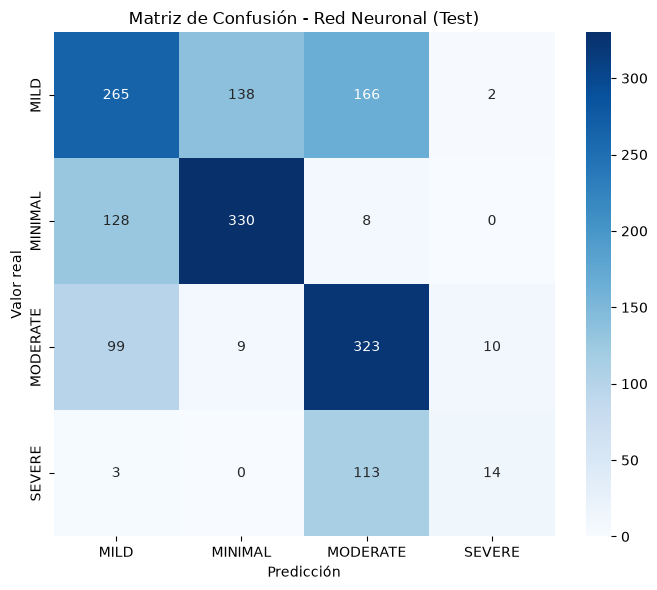

In [10]:
# ==========================================
# 8. PREDICCIONES SOBRE TEST
# ==========================================

best_model.eval()

with torch.no_grad():

    test_logits = best_model(X_test_tensor)

    # Obtener la clase con mayor probabilidad
    y_pred_tensor = torch.argmax(
        test_logits,
        dim=1
    )


# Convertimos a NumPy
y_pred = y_pred_tensor.numpy()

y_test_np = y_test_tensor.numpy()


# ==========================================
# 9. MÉTRICAS
# ==========================================

accuracy = accuracy_score(
    y_test_np,
    y_pred
)

precision = precision_score(
    y_test_np,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test_np,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test_np,
    y_pred,
    average='weighted'
)


# ==========================================
# 10. MOSTRAR MÉTRICAS
# ==========================================

print("\n==============================================")
print("       MÉTRICAS EN TEST (RED NEURONAL)")
print("==============================================")

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")

print()


# ==========================================
# 11. CLASSIFICATION REPORT
# ==========================================

print("==============================================")
print("              CLASSIFICATION REPORT")
print("==============================================")

print(
    classification_report(
        y_test_np,
        y_pred,
        target_names=le.classes_
    )
)


# ==========================================
# 12. MATRIZ DE CONFUSIÓN
# ==========================================

cm = confusion_matrix(
    y_test_np,
    y_pred
)


plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.title(
    'Matriz de Confusión - Red Neuronal (Test)'
)

plt.tight_layout()

plt.show()